In [1]:
import sys, os
while not os.path.isdir('src') and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir('..')
sys.path.insert(0, 'src')

import numpy as np, torch, json
import matplotlib.pyplot as plt

from tradinglab.data_feed import DataFeed
from tradinglab.features import build_pooled_dataset, build_pooled_sequences
from tradinglab.models import MLP, LSTMRegressor
from tradinglab.ml import train_model, predict
from tradinglab.metrics import information_coefficient
from tradinglab.strategies.predictor import predictions_to_weights, model_to_strategy
from tradinglab.simulator import PortfolioSimulator
from tradinglab.backtester import run_backtest
from tradinglab.report import report

os.makedirs('dashboard/data', exist_ok=True)

TOP_K = 4
SEQ_LEN = 10
EPOCHS_MLP = 500
EPOCHS_LSTM = 150

feed = DataFeed.from_dir('data/egx')
split_day = int(feed.n_days * 0.7)
sim = PortfolioSimulator(feed)

In [2]:
# MLP: one row per (asset, day)
X_train, y_train, X_test, y_test = build_pooled_dataset(feed, split_day)
n_features = X_train.shape[1]

# LSTM: sequences of seq_len days per (asset, day)
Xtr_s, ytr_s, Xte_s, yte_s = build_pooled_sequences(feed, split_day, seq_len=SEQ_LEN)

print(f'MLP dataset:  {len(X_train)} train / {len(X_test)} test rows')
print(f'LSTM dataset: {len(Xtr_s)} train / {len(Xte_s)} test sequences')

c:\Users\youse\Documents\2026-orion\src\tradinglab\features.py:64: RuntimeWarning: invalid value encountered in divide
  volume_ratio = volume / vol_avg20


MLP dataset:  26588 train / 11798 test rows
LSTM dataset: 26248 train / 11458 test sequences


In [3]:
torch.manual_seed(0)
mlp = MLP(n_features, hidden=32)
mlp_history = train_model(mlp, X_train, y_train, X_test, y_test, epochs=EPOCHS_MLP)
mlp_ic = information_coefficient(predict(mlp, X_test), y_test)

torch.manual_seed(0)
lstm = LSTMRegressor(n_features=n_features, hidden=32)
lstm_history = train_model(lstm, Xtr_s, ytr_s, Xte_s, yte_s, epochs=EPOCHS_LSTM)
lstm_ic = information_coefficient(predict(lstm, Xte_s), yte_s)

print(f'MLP  — final test loss {mlp_history["test"][-1]:.5f} | IC {mlp_ic:+.3f}')
print(f'LSTM — final test loss {lstm_history["test"][-1]:.5f} | IC {lstm_ic:+.3f}')

MLP  — final test loss 0.00058 | IC +0.015
LSTM — final test loss 0.00059 | IC -0.008


In [4]:
def lstm_to_strategy(model, seq_len, top_k=2):
    def strategy(observation):
        window = observation[:, -seq_len:, :]
        preds = predict(model, window.astype('float32'))
        return predictions_to_weights(preds, top_k)
    return strategy

mlp_strategy = model_to_strategy(mlp, top_k=TOP_K)
lstm_strategy = lstm_to_strategy(lstm, seq_len=SEQ_LEN, top_k=TOP_K)

c:\Users\youse\Documents\2026-orion\src\tradinglab\features.py:64: RuntimeWarning: invalid value encountered in divide
  volume_ratio = volume / vol_avg20


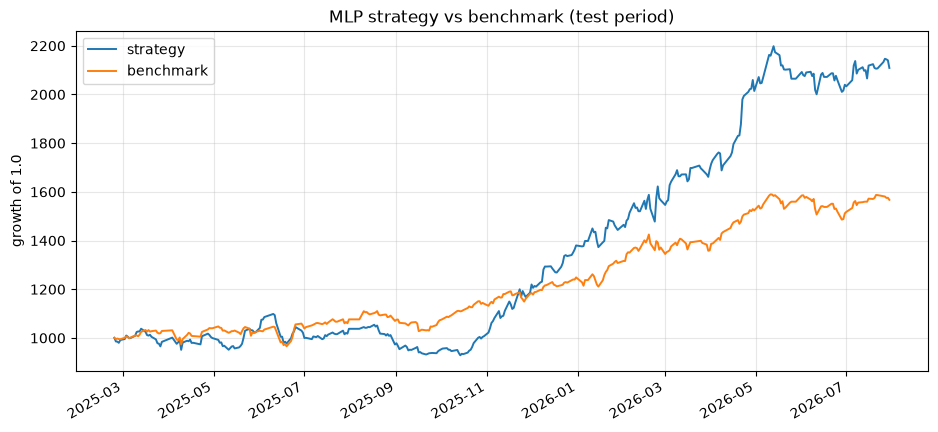

total return   : +110.9%
sharpe         : 2.39
max drawdown   : 15.5%
final value    : 2108.95   (benchmark 1567.20)
beat benchmark : YES
                 you beat the benchmark by 542 EGP


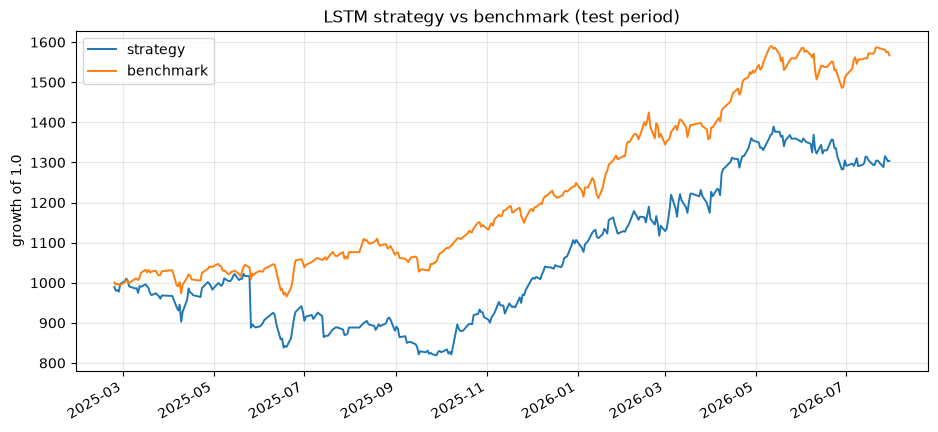

total return   : +30.4%
sharpe         : 0.90
max drawdown   : 19.9%
final value    : 1303.91   (benchmark 1567.20)
beat benchmark : no
                 you lost to the benchmark by 263 EGP


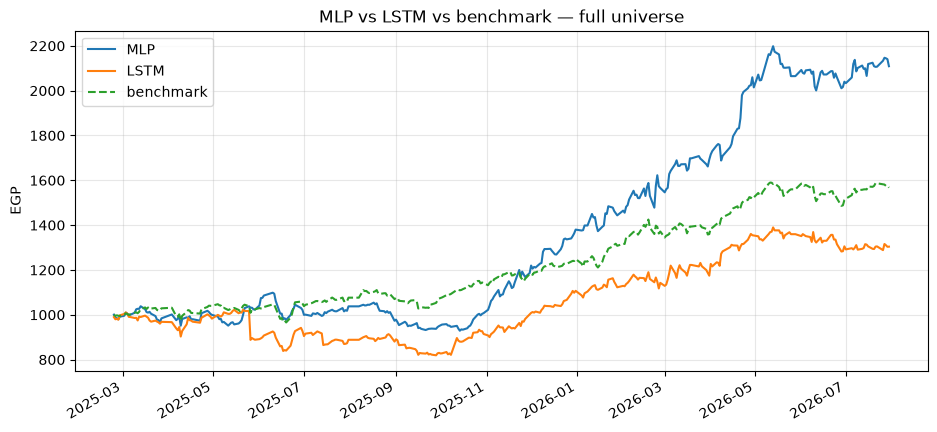

MLP final : 2,109 EGP
LSTM final: 1,304 EGP
benchmark : 1,567 EGP


In [5]:
split = split_day
result_mlp = run_backtest(sim, mlp_strategy, lookback=30, start=split)
result_lstm = run_backtest(sim, lstm_strategy, lookback=30, start=split)

report(result_mlp, title='MLP strategy vs benchmark (test period)', start_capital=1000.0)
report(result_lstm, title='LSTM strategy vs benchmark (test period)', start_capital=1000.0)

START = 1000.0
dates = result_mlp['dates']
plt.figure(figsize=(11, 5))
plt.plot(dates, result_mlp['portfolio']*START, label='MLP')
plt.plot(dates, result_lstm['portfolio']*START, label='LSTM')
plt.plot(dates, result_mlp['benchmark']*START, label='benchmark', linestyle='--')
plt.legend(); plt.grid(alpha=0.3); plt.ylabel('EGP')
plt.title('MLP vs LSTM vs benchmark — full universe')
plt.gcf().autofmt_xdate(); plt.show()

print(f"MLP final : {result_mlp['portfolio'][-1]*START:,.0f} EGP")
print(f"LSTM final: {result_lstm['portfolio'][-1]*START:,.0f} EGP")
print(f"benchmark : {result_mlp['benchmark'][-1]*START:,.0f} EGP")

In [6]:
N_SEEDS = 6
rows = []

for seed in range(N_SEEDS):
    torch.manual_seed(seed)
    m_mlp = MLP(n_features, hidden=32)
    train_model(m_mlp, X_train, y_train, X_test, y_test, epochs=EPOCHS_MLP)
    ic_mlp = information_coefficient(predict(m_mlp, X_test), y_test)
    res_mlp = run_backtest(sim, model_to_strategy(m_mlp, top_k=TOP_K), lookback=30, start=split)
    final_mlp = res_mlp['portfolio'][-1] * START

    torch.manual_seed(seed)
    m_lstm = LSTMRegressor(n_features=n_features, hidden=32)
    train_model(m_lstm, Xtr_s, ytr_s, Xte_s, yte_s, epochs=EPOCHS_LSTM)
    ic_lstm = information_coefficient(predict(m_lstm, Xte_s), yte_s)
    res_lstm = run_backtest(sim, lstm_to_strategy(m_lstm, seq_len=SEQ_LEN, top_k=TOP_K), lookback=30, start=split)
    final_lstm = res_lstm['portfolio'][-1] * START

    bench = res_mlp['benchmark'][-1] * START
    rows.append((seed, ic_mlp, final_mlp, ic_lstm, final_lstm, bench))
    print(f"seed {seed} | MLP IC {ic_mlp:+.3f} final {final_mlp:8,.0f}  ||  "
          f"LSTM IC {ic_lstm:+.3f} final {final_lstm:8,.0f}  ||  benchmark {bench:8,.0f}")

mlp_wins = sum(1 for r in rows if r[2] > r[5])
lstm_wins = sum(1 for r in rows if r[4] > r[5])
mlp_beats_lstm = sum(1 for r in rows if r[2] > r[4])

print(f"\nMLP beat benchmark  in {mlp_wins}/{N_SEEDS} runs")
print(f"LSTM beat benchmark in {lstm_wins}/{N_SEEDS} runs")
print(f"MLP beat LSTM       in {mlp_beats_lstm}/{N_SEEDS} runs")

seed 0 | MLP IC +0.015 final    2,109  ||  LSTM IC -0.008 final    1,304  ||  benchmark    1,567
seed 1 | MLP IC +0.019 final    2,311  ||  LSTM IC -0.005 final    1,328  ||  benchmark    1,567
seed 2 | MLP IC +0.010 final    2,467  ||  LSTM IC -0.021 final    1,362  ||  benchmark    1,567
seed 3 | MLP IC +0.010 final    2,017  ||  LSTM IC -0.015 final    1,099  ||  benchmark    1,567
seed 4 | MLP IC +0.018 final    2,200  ||  LSTM IC -0.025 final    1,599  ||  benchmark    1,567
seed 5 | MLP IC +0.028 final    1,419  ||  LSTM IC +0.007 final    1,496  ||  benchmark    1,567

MLP beat benchmark  in 5/6 runs
LSTM beat benchmark in 1/6 runs
MLP beat LSTM       in 5/6 runs


In [7]:
compare_data = {
    "mlp_test_loss": round(mlp_history["test"][-1], 6),
    "lstm_test_loss": round(lstm_history["test"][-1], 6),
    "mlp_ic": round(mlp_ic, 4),
    "lstm_ic": round(lstm_ic, 4),
    "mlp_final_value": round(result_mlp['portfolio'][-1] * START, 2),
    "lstm_final_value": round(result_lstm['portfolio'][-1] * START, 2),
    "benchmark_final_value": round(result_mlp['benchmark'][-1] * START, 2),
}

json.dump(compare_data, open('dashboard/data/model_compare.json', 'w'), indent=2)
print(json.dumps(compare_data, indent=2))

{
  "mlp_test_loss": 0.000581,
  "lstm_test_loss": 0.000587,
  "mlp_ic": 0.015,
  "lstm_ic": -0.0078,
  "mlp_final_value": 2108.95,
  "lstm_final_value": 1303.91,
  "benchmark_final_value": 1567.2
}
